In [28]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# For countplot charts
count_palette = {0: 'steelblue', 1: 'darkorange'}

# For histplot charts  
hist_palette = {0: 'darkorange', 1: 'steelblue'}

# Load the dataset
df = pd.read_csv('Customer-Churn-Records.csv')

In [2]:
# Explore the dataset
df.shape
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [3]:
# Check for missing values
print(df.isnull().sum())

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


In [4]:
# Check dataset balance of the target variable 'Exited'
print("Dataset balance of column 'Exited':")
df['Exited'].value_counts()

# Check the proportion of customers who churned vs those who did not
print("Proportion of customers who churned vs those who did not:")
df['Exited'].value_counts(normalize = True)

Dataset balance of column 'Exited':
Proportion of customers who churned vs those who did not:


Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

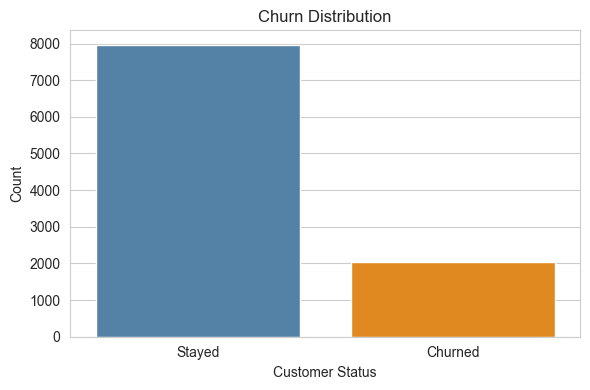

In [29]:
# Visualize the distribution of the target variable 'Exited'
# Churn distribution
sns.set_style("whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', hue='Exited', data=df, palette=count_palette, legend=False)
plt.title('Churn Distribution')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.xlabel('Customer Status')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('churn_distribution.png')
plt.show()

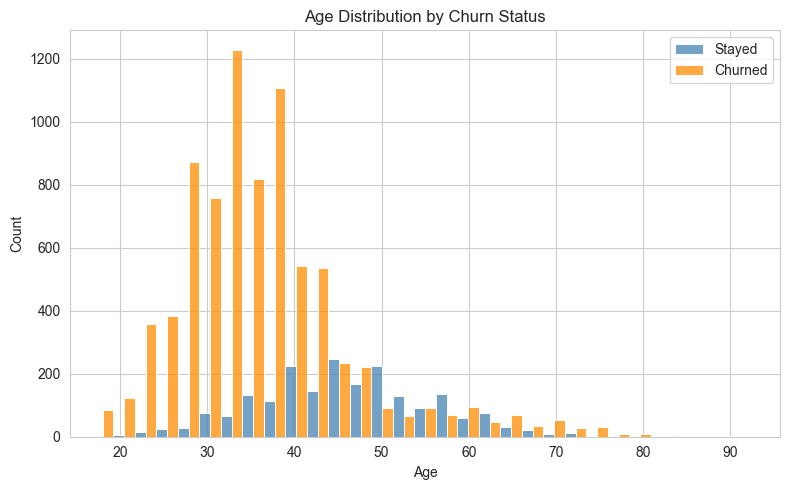

In [ ]:
# Which factors are associated with customers leaving?
# The business logic: start with the features most likely to be strong predictors based on business intuition.
# 1. Age: Older customers may have different needs and may be more likely to churn if those needs are not met.

# Age distribution by churn status
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Exited', bins=30,
             palette=hist_palette, multiple='dodge',
             hue_order=[0, 1])
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_age.png')
plt.show()

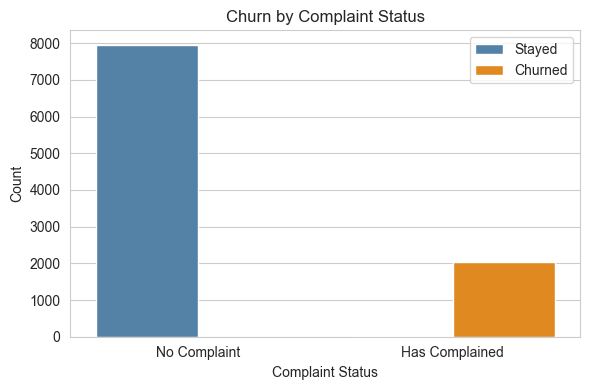

In [ ]:
# The business logic: A customer who has complained is already signaling dissatisfaction.
# 2. Complaint status: Does complaining actually predict whether they leave?

# Churn rate by complaint status
plt.figure(figsize=(6, 4))
sns.countplot(x='Complain', hue='Exited', data=df, palette=count_palette)
plt.title('Churn by Complaint Status')
plt.xticks([0, 1], ['No Complaint', 'Has Complained'])
plt.xlabel('Complaint Status')
plt.ylabel('Count')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_complaint.png')
plt.show()

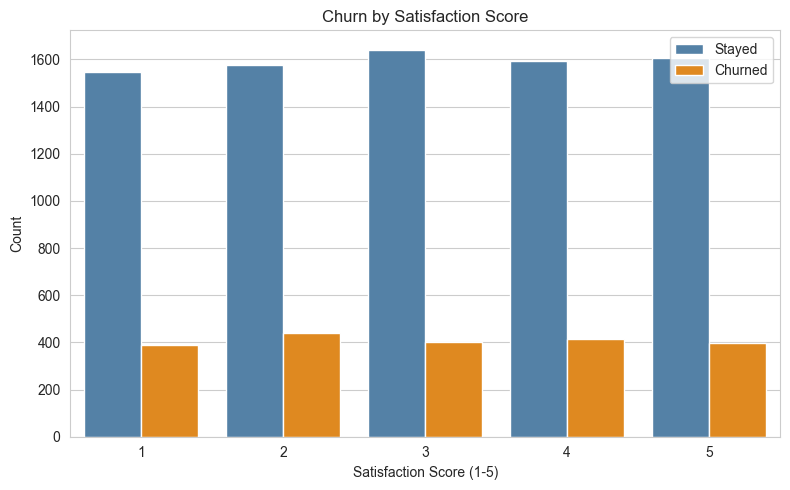

In [34]:
# The business logic: a customer who rates their experience low is signaling unhappiness.
# 3. Satisfaction score: Does a low satisfaction score predict churn?

# Churn rate by satisfaction score
plt.figure(figsize=(8, 5))
sns.countplot(x='Satisfaction Score', hue='Exited', data=df, palette=count_palette)
plt.title('Churn by Satisfaction Score')
plt.xlabel('Satisfaction Score (1-5)')
plt.ylabel('Count')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_satisfaction.png')
plt.show()

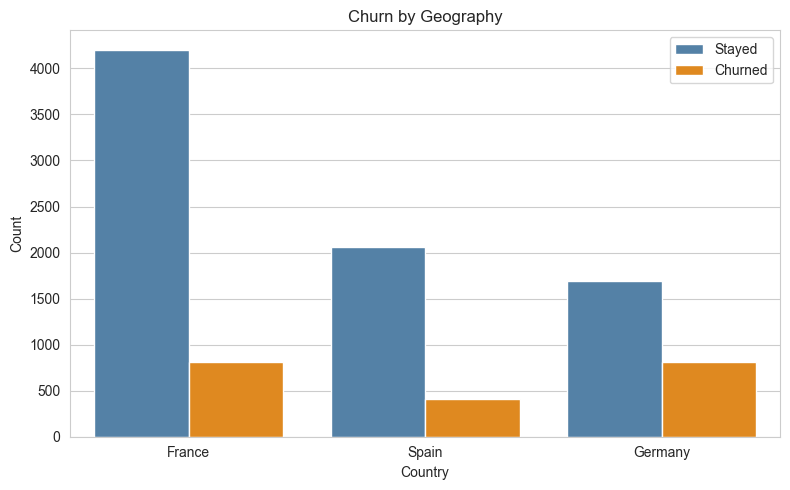

In [35]:
# 4. Geography: Are customers from certain regions more likely to churn?
# Churn rate by geography
plt.figure(figsize=(8, 5))
sns.countplot(x='Geography', hue='Exited', data=df, palette=count_palette)
plt.title('Churn by Geography')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_geography.png')
plt.show()

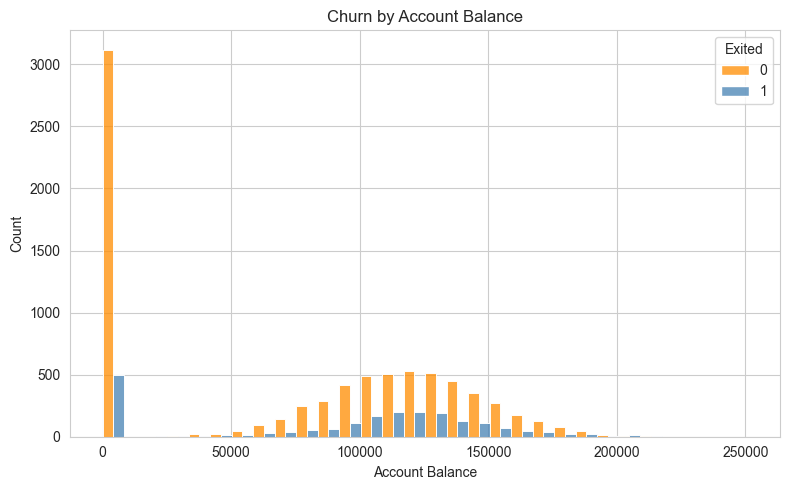

In [37]:
# The business logic: customers with higher balances have more at stake and may be more valuable to retain
# but they may also have more options and be more likely to switch to a competitor offering better returns.
# Bank balance: Do customers with lower balances churn more?

# Churn rate by account balance
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Balance', hue='Exited', bins=30,
             palette=hist_palette, multiple='dodge',
             hue_order=[0, 1])
plt.title('Churn by Account Balance')
plt.xlabel('Account Balance')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('churn_by_balance.png')
plt.show()